## **Title: Exploratory Data Analysis of Swiggy Food Delivery Dataset Using Python**

**Aim:** 
To analyze and visualize food delivery data from Swiggy in order to understand restaurant distribution, ratings, pricing, and popular food categories using Python data analysis libraries.

#### **Objectives:**
* To identify the most popular restaurants and dishes based on customer orders

* To analyze the relationship between pricing and customer ratings

* To examine order trends based on months and days

* To determine the highest-rated food categories

### **Import Libraries** 

In [205]:
import pandas as pd              # Used for data handling and analysis (tables, CSV, Excel)
import numpy as np               # Used for numerical operations and arrays
import matplotlib.pyplot as plt      # Used for creating graphs and plots
import seaborn as sns            # Used for attractive and statistical visualizations
from matplotlib import style     # Used to apply different plotting styles


### **Set style for better visualizations**

In [206]:
style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### **Load Dataset**

In [207]:
df = pd.read_csv(r"Swiggy Raw Dataset.csv")
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,6/29/2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,4/3/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,1/15/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,4/17/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,3/13/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


### **Basic Dataset Information**

In [208]:
df.shape

(197430, 10)

In [209]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Order Date       197430 non-null  object 
 3   Restaurant Name  197430 non-null  object 
 4   Location         197430 non-null  object 
 5   Category         197430 non-null  object 
 6   Dish Name        197430 non-null  object 
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 15.1+ MB


,Price (INR),Rating,Rating Count
count,197430.000000,197430.000000,197430.000000
mean,268.512920,4.341582,28.321805
std,219.338363,0.422585,87.542593
min,0.950000,1.500000,0.000000
25%,139.000000,4.300000,0.000000
50%,229.000000,4.400000,2.000000
75%,329.000000,4.500000,15.000000
max,8000.000000,5.000000,999.000000


**Check data types and missing values**


In [210]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Data Types:
State               object
City                object
Order Date          object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

Missing Values:
State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64


**Standardize date format**

In [211]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

**Extract month and day of week**

In [212]:
df['Month'] = df['Order Date'].dt.month
df['Day_of_Week'] = df['Order Date'].dt.day_name()

**Remove duplicates (considering all columns)**

In [213]:
initial_rows = len(df)
df = df.drop_duplicates()
removed_duplicates = initial_rows - len(df)
print(f"Removed {removed_duplicates} duplicate rows")

Removed 27 duplicate rows


### **BASIC STATISTICAL ANALYSIS**

In [214]:
print(f"\nPrice Statistics:")
print(f"Average Price: ₹{df['Price (INR)'].mean():.2f}")
print(f"Maximum Price: ₹{df['Price (INR)'].max():.2f}")
print(f"Minimum Price: ₹{df['Price (INR)'].min():.2f}")
print(f"Median Price: ₹{df['Price (INR)'].median():.2f}")

print(f"\nRating Statistics:")
print(f"Average Rating: {df['Rating'].mean():.2f}")
print(f"Maximum Rating: {df['Rating'].max():.2f}")
print(f"Minimum Rating: {df['Rating'].min():.2f}")


Price Statistics:
Average Price: ₹268.50
Maximum Price: ₹8000.00
Minimum Price: ₹0.95
Median Price: ₹229.00

Rating Statistics:
Average Rating: 4.34
Maximum Rating: 5.00
Minimum Rating: 1.50


### **RESTAURANT ANALYSIS**

**Top restaurants by number of dishes**

In [216]:
restaurant_counts = df['Restaurant Name'].value_counts().head(10)            # Counts how many dishes each restaurant has and selects top 10

print(f"\nTop 10 Restaurants by Number of Dishes Listed:")                   # Prints heading message

for i, (restaurant, count) in enumerate(restaurant_counts.items(), 1):       # Loops through each restaurant with ranking number
    print(f"{i}. {restaurant}: {count} dishes")                              # Displays restaurant name with total number of dishes



Top 10 Restaurants by Number of Dishes Listed:
1. McDonald's: 13528 dishes
2. KFC: 12957 dishes
3. Burger King: 7115 dishes
4. Pizza Hut: 6529 dishes
5. Domino's Pizza: 5489 dishes
6. LunchBox - Meals and Thalis: 4700 dishes
7. Baskin Robbins - Ice Cream Desserts: 4197 dishes
8. Faasos - Wraps, Rolls & Shawarma: 3256 dishes
9. Olio - The Wood Fired Pizzeria: 3239 dishes
10. The Good Bowl: 2665 dishes


**Top restaurants by average rating (with sufficient ratings)**

In [217]:
restaurant_stats = df.groupby('Restaurant Name').agg({
    'Rating': 'mean',
    'Rating Count': 'sum',
    'Price (INR)': 'mean',
    'Dish Name': 'count'
}).rename(columns={'Dish Name': 'Dish Count'})

# Filter restaurants with at least 10 ratings
top_rated_restaurants = restaurant_stats[restaurant_stats['Rating Count'] >= 10].sort_values('Rating', ascending=False).head(10)

print(f"\nTop 10 Restaurants by Average Rating (min 10 reviews):")
for i, (restaurant, row) in enumerate(top_rated_restaurants.iterrows(), 1):
    print(f"{i}. {restaurant}: Rating {row['Rating']:.2f} ({row['Rating Count']} reviews)")



Top 10 Restaurants by Average Rating (min 10 reviews):
1. Sakana: Rating 4.82 (2155.0 reviews)
2. Jagannath Mandir Arna Prasad: Rating 4.75 (288.0 reviews)
3. Vijay Dairy: Rating 4.75 (539.0 reviews)
4. Radhey Lal's Parampara Sweets: Rating 4.74 (12090.0 reviews)
5. I Deli Cafe: Rating 4.74 (3600.0 reviews)
6. Yadav Doodh Dairy: Rating 4.73 (2609.0 reviews)
7. Tossin Pizza: Rating 4.71 (8978.0 reviews)
8. Perambur Sri Srinivasa Sweets & Snacks: Rating 4.71 (244.0 reviews)
9. Wooden Plate: Rating 4.69 (4257.0 reviews)
10. Natural Ice Cream: Rating 4.68 (11567.0 reviews)


### **CATEGORY ANALYSIS** 

In [218]:
category_stats = df.groupby('Category').agg({
    'Dish Name': 'count',
    'Price (INR)': 'mean',
    'Rating': 'mean'
}).rename(columns={'Dish Name': 'Dish Count', 'Price (INR)': 'Avg Price', 'Rating': 'Avg Rating'})

print(f"\nCategory Statistics:")
print(category_stats.sort_values('Dish Count', ascending=False).head(10))


Category Statistics:
                                 Dish Count   Avg Price  Avg Rating
Category                                                           
Recommended                           24098  298.293324    4.321790
Main Course                            2959  256.858736    4.310848
Desserts                               2943  141.410900    4.367312
Beverages                              2464   91.454298    4.368222
McSaver Combos (2 Pc Meals)            1884  228.947266    4.413800
Exclusive Deals (Save upto 40%)        1717  223.278556    4.348806
Sweets                                 1715  226.122682    4.463790
Starters                               1673  238.347878    4.304304
Breads                                 1422   85.172658    4.347820
Snacks                                 1386  126.563557    4.313276


### **VISUALIZATION SECTION**

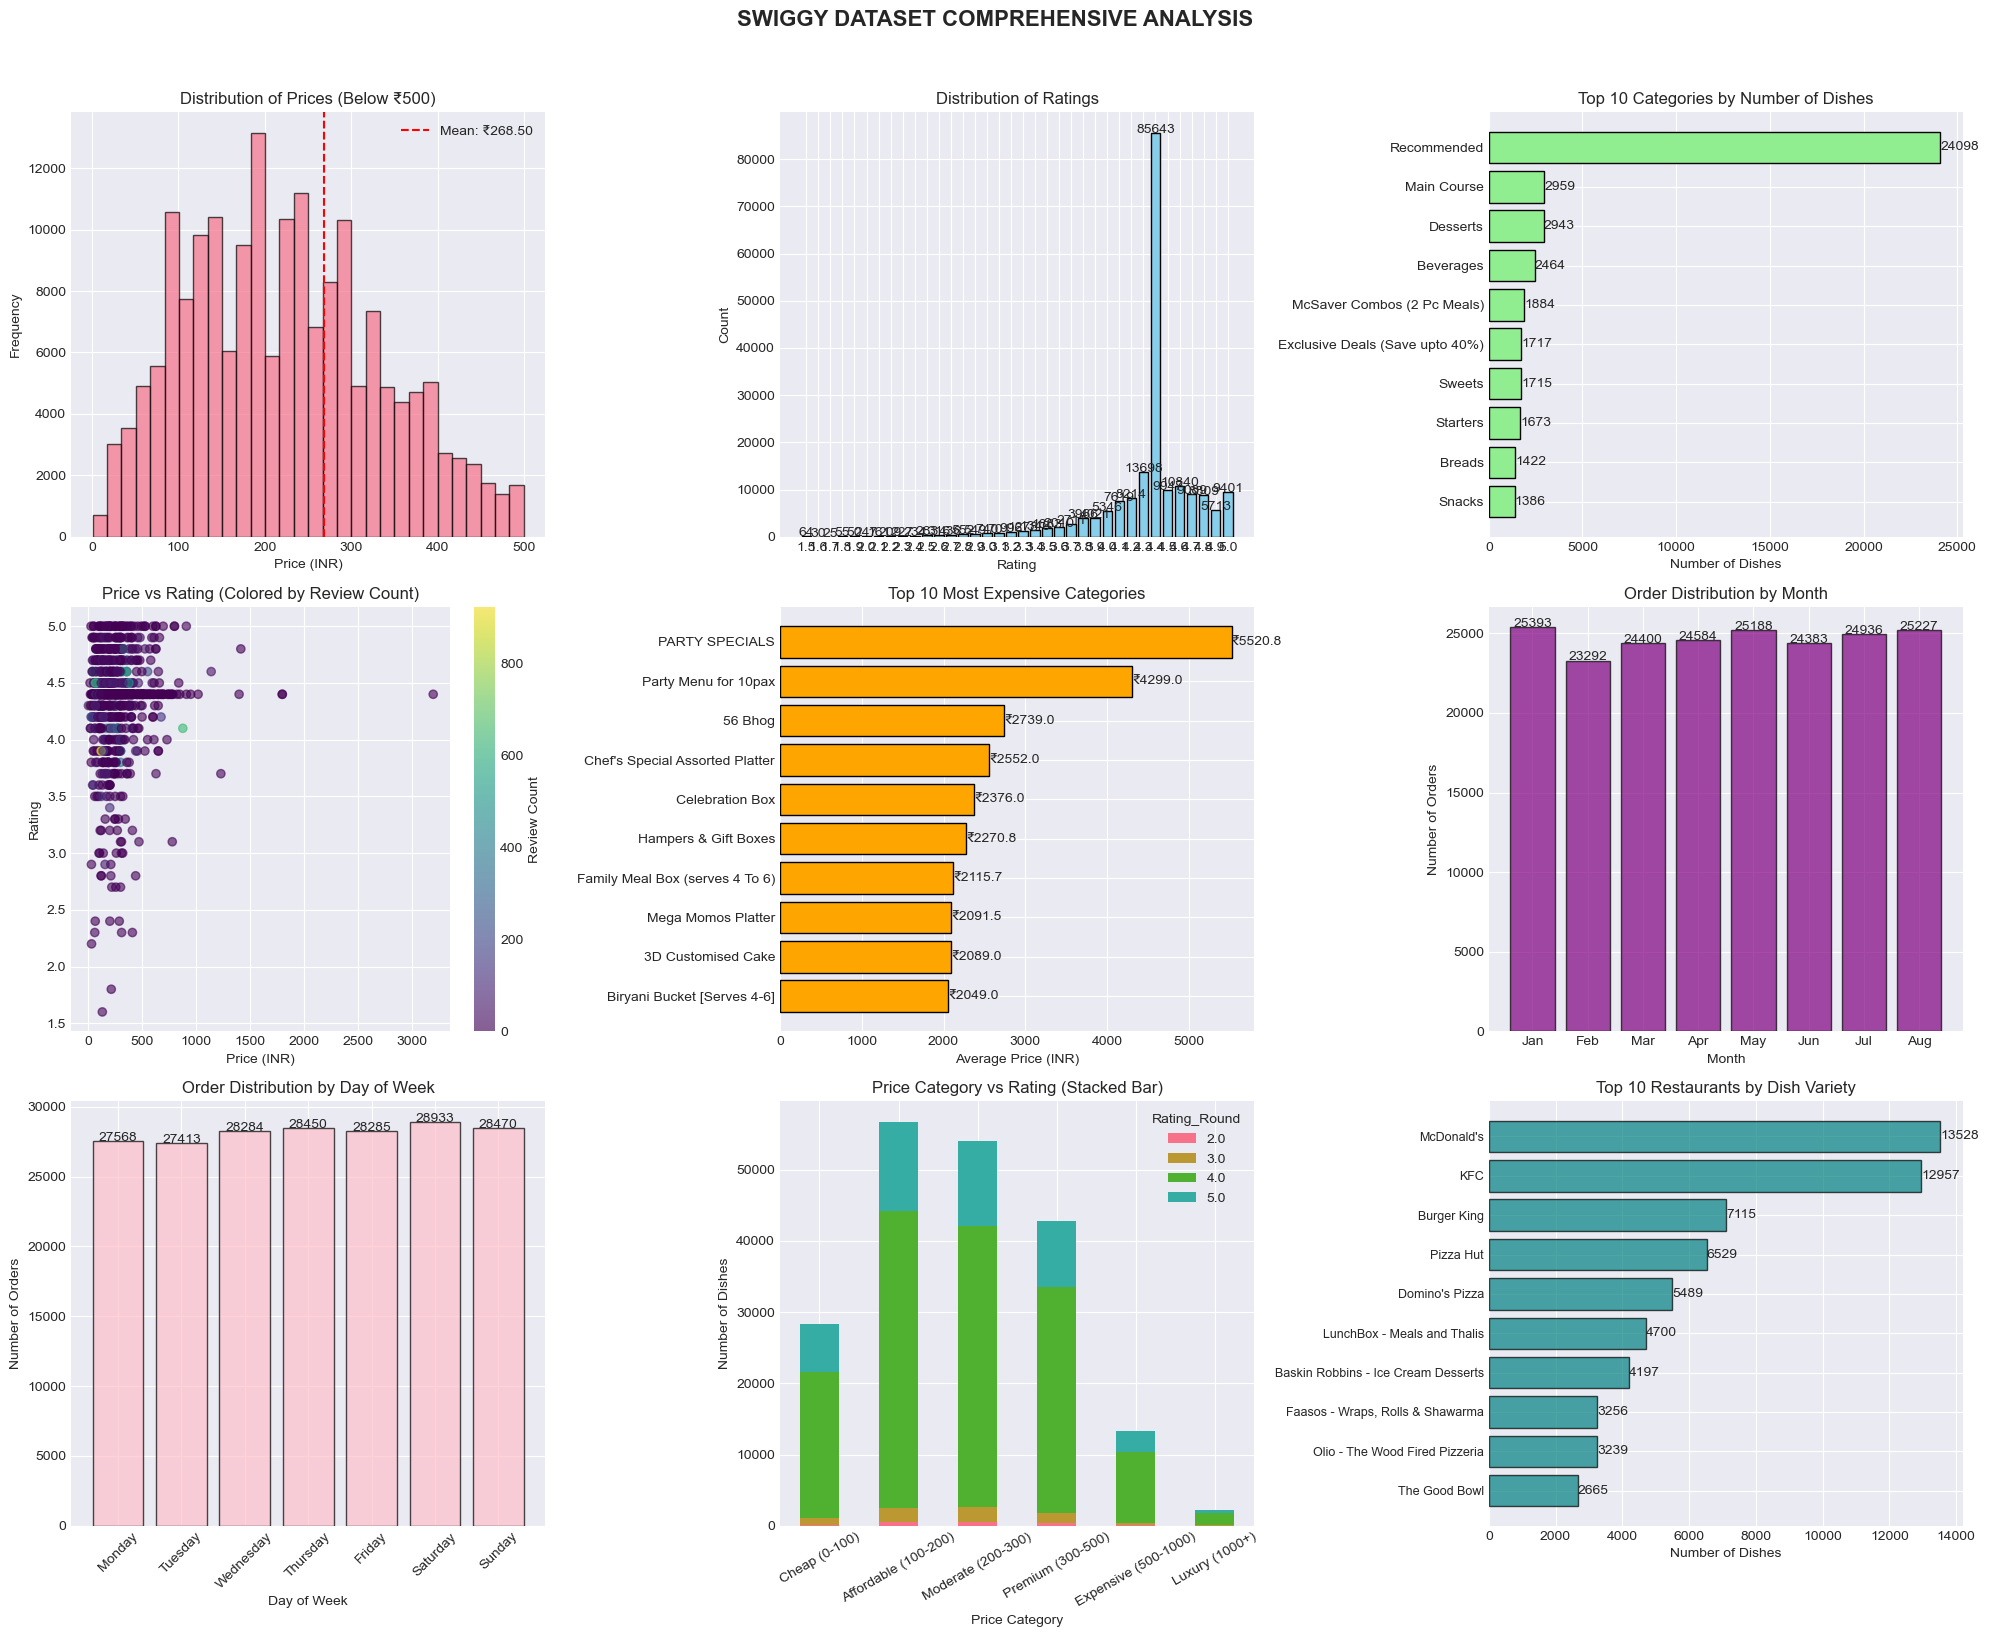

In [219]:
# Create main figure with 3x3 subplots
fig = plt.figure(figsize=(20, 16))

# 1. Price Distribution
ax1 = plt.subplot(3, 3, 1)
price_data = df['Price (INR)']
ax1.hist(price_data[price_data < 500], bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Price (INR)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Prices (Below ₹500)')
ax1.axvline(price_data.mean(), color='red', linestyle='--', label=f'Mean: ₹{price_data.mean():.2f}')
ax1.legend()

# 2. Rating Distribution
ax2 = plt.subplot(3, 3, 2)
rating_counts = df['Rating'].value_counts().sort_index()
ax2.bar(rating_counts.index.astype(str), rating_counts.values, color='skyblue', edgecolor='black')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Ratings')
for i, v in enumerate(rating_counts.values):
    ax2.text(i, v + 5, str(v), ha='center')

# 3. Top Categories by Dish Count
ax3 = plt.subplot(3, 3, 3)
top_categories = category_stats.sort_values('Dish Count', ascending=False).head(10)
bars = ax3.barh(top_categories.index, top_categories['Dish Count'], color='lightgreen', edgecolor='black')
ax3.set_xlabel('Number of Dishes')
ax3.set_title('Top 10 Categories by Number of Dishes')
ax3.invert_yaxis()
for i, (category, count) in enumerate(zip(top_categories.index, top_categories['Dish Count'])):
    ax3.text(count + 2, i, str(int(count)), va='center')

# 4. Price vs Rating Scatter
ax4 = plt.subplot(3, 3, 4)
sampled_data = df.sample(min(1000, len(df)), random_state=42)
scatter = ax4.scatter(sampled_data['Price (INR)'], sampled_data['Rating'], 
                     alpha=0.6, c=sampled_data['Rating Count'], cmap='viridis')
ax4.set_xlabel('Price (INR)')
ax4.set_ylabel('Rating')
ax4.set_title('Price vs Rating (Colored by Review Count)')
plt.colorbar(scatter, ax=ax4, label='Review Count')

# 5. Average Price by Category
ax5 = plt.subplot(3, 3, 5)
price_by_category = category_stats.sort_values('Avg Price', ascending=False).head(10)
bars = ax5.barh(price_by_category.index, price_by_category['Avg Price'], color='orange', edgecolor='black')
ax5.set_xlabel('Average Price (INR)')
ax5.set_title('Top 10 Most Expensive Categories')
ax5.invert_yaxis()
for i, (category, price) in enumerate(zip(price_by_category.index, price_by_category['Avg Price'])):
    ax5.text(price + 5, i, f'₹{price:.1f}', va='center')

# 6. Monthly Order Distribution
ax6 = plt.subplot(3, 3, 6)
monthly_orders = df['Month'].value_counts().sort_index()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
ax6.bar(months, monthly_orders.values, color='purple', alpha=0.7, edgecolor='black')
ax6.set_xlabel('Month')
ax6.set_ylabel('Number of Orders')
ax6.set_title('Order Distribution by Month')
for i, v in enumerate(monthly_orders.values):
    ax6.text(i, v + 5, str(v), ha='center')

# 7. Day of Week Analysis
ax7 = plt.subplot(3, 3, 7)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Day_of_Week'].value_counts().reindex(day_order)
ax7.bar(day_counts.index, day_counts.values, color='pink', alpha=0.7, edgecolor='black')
ax7.set_xlabel('Day of Week')
ax7.set_ylabel('Number of Orders')
ax7.set_title('Order Distribution by Day of Week')
plt.xticks(rotation=45)
for i, v in enumerate(day_counts.values):
    ax7.text(i, v + 5, str(v), ha='center')
    
# 8. Price Category Distribution
ax8 = plt.subplot(3, 3, 8)
bins = [0, 100, 200, 300, 500, 1000, df['Price (INR)'].max() + 1]
labels = ['Cheap (0-100)', 'Affordable (100-200)', 
         'Moderate (200-300)', 'Premium (300-500)',
         'Expensive (500-1000)', 'Luxury (1000+)']
df['Price_Category'] = pd.cut(df['Price (INR)'], bins=bins, labels=labels)
df['Rating_Round'] = df['Rating'].round()
stacked_data = pd.crosstab(df['Price_Category'], df['Rating_Round'])
stacked_data = stacked_data.dropna(how='all')
stacked_data.plot(kind='bar', stacked=True, ax=ax8)
ax8.set_xlabel('Price Category')
ax8.set_ylabel('Number of Dishes')
ax8.set_title('Price Category vs Rating (Stacked Bar)')
plt.xticks(rotation=30)

# 9. Top Restaurants by Dish Variety
ax9 = plt.subplot(3, 3, 9)
top_restaurants = restaurant_stats.sort_values('Dish Count', ascending=False).head(10)
bars = ax9.barh(range(len(top_restaurants)), top_restaurants['Dish Count'], color='teal', alpha=0.7, edgecolor='black')
ax9.set_yticks(range(len(top_restaurants)))
ax9.set_yticklabels(top_restaurants.index, fontsize=9)
ax9.set_xlabel('Number of Dishes')
ax9.set_title('Top 10 Restaurants by Dish Variety')
ax9.invert_yaxis()
for i, count in enumerate(top_restaurants['Dish Count']):
    ax9.text(count + 2, i, str(int(count)), va='center')

plt.suptitle('SWIGGY DATASET COMPREHENSIVE ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Top 10 Most Reviewed Dishes**


Analyzing top dishes...


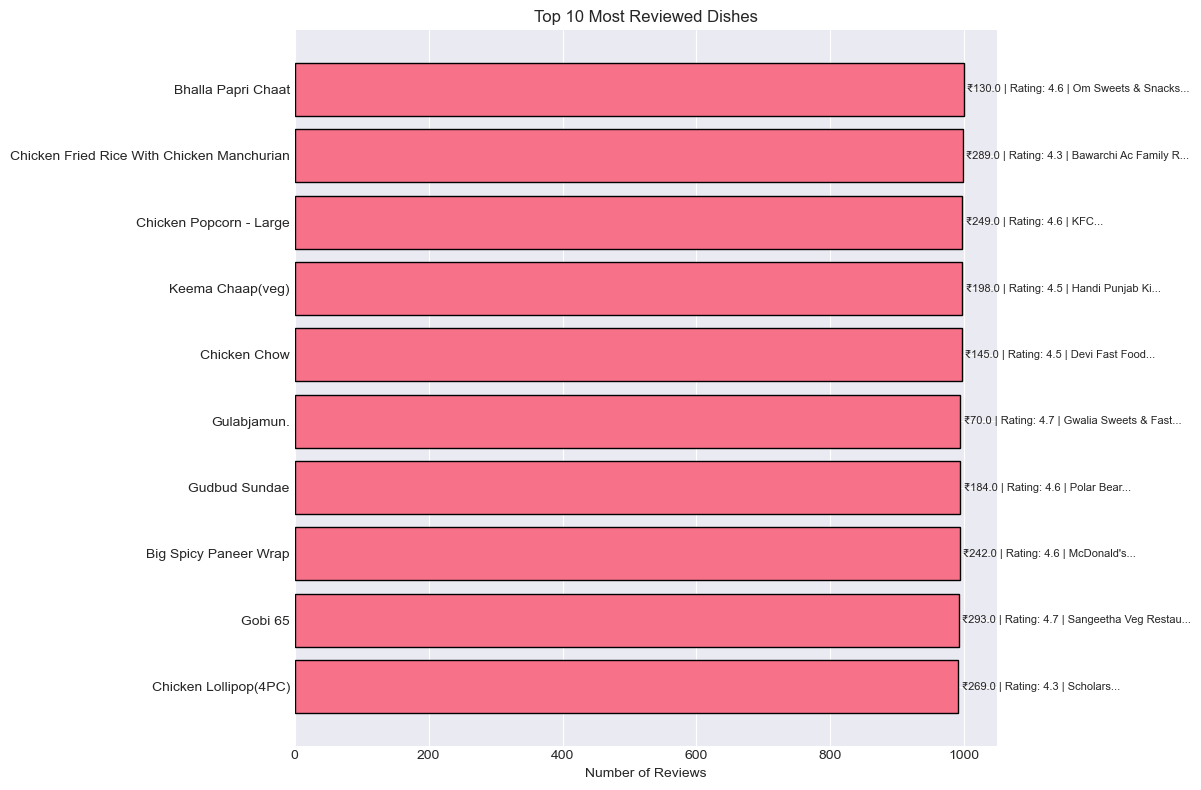

In [220]:
# 10. Top 10 Most Reviewed Dishes
print("\nAnalyzing top dishes...")

top_dishes = (
    df.sort_values('Rating Count', ascending=False)
      .drop_duplicates('Dish Name')
      .head(10)
)[['Dish Name', 'Restaurant Name', 'Rating', 'Rating Count', 'Price (INR)']]

fig3, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_dishes))

ax.barh(y_pos, top_dishes['Rating Count'], edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_dishes['Dish Name'], fontsize=10)
ax.set_xlabel('Number of Reviews')
ax.set_title('Top 10 Most Reviewed Dishes')
ax.invert_yaxis()

for i, (_, row) in enumerate(top_dishes.iterrows()):
    ax.text(
        row['Rating Count'] + 5, i,
        f"₹{row['Price (INR)']} | Rating: {row['Rating']} | {row['Restaurant Name'][:20]}...",
        va='center', fontsize=8
    )

plt.tight_layout()
plt.show()


**Analysis: Correlation Matrix**


Generating correlation matrix...


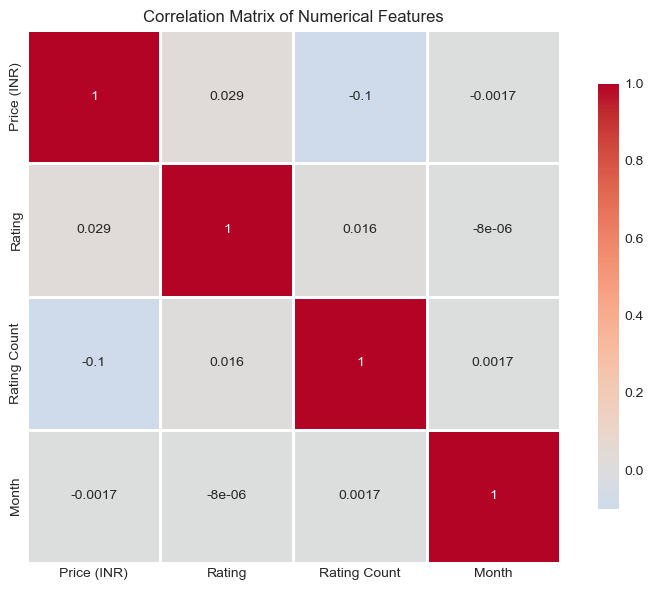

In [221]:
# 11. Correlation Matrix of Numerical Features
print("\nGenerating correlation matrix...")

# Select numerical columns for correlation
numerical_df = df[['Price (INR)', 'Rating', 'Rating Count', 'Month']]
correlation_matrix = numerical_df.corr()

fig2, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### **KEY INSIGHTS SUMMARY**

In [222]:
print(f"\n1. DATASET OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Unique restaurants: {df['Restaurant Name'].nunique()}")
print(f"   • Price range: ₹{df['Price (INR)'].min():.2f} to ₹{df['Price (INR)'].max():.2f}")
print(f"   • Average rating: {df['Rating'].mean():.2f}/5")

print(f"\n2. POPULAR CATEGORIES:")
top_3_categories = category_stats.sort_values('Dish Count', ascending=False).head(3)
for cat, row in top_3_categories.iterrows():
    print(f"   • {cat}: {int(row['Dish Count'])} dishes, Avg price: ₹{row['Avg Price']:.2f}")

print(f"\n3. PRICE DISTRIBUTION:")
price_stats = df['Price (INR)'].describe()
print(f"   • 25% of dishes cost less than: ₹{price_stats['25%']:.2f}")
print(f"   • 50% of dishes cost less than: ₹{price_stats['50%']:.2f}")
print(f"   • 75% of dishes cost less than: ₹{price_stats['75%']:.2f}")

print(f"\n4. MONTHLY TRENDS:")
print(f"   • Most orders in month: {months[monthly_orders.idxmax() - 1]} ({monthly_orders.max()} orders)")
print(f"   • Least orders in month: {months[monthly_orders.idxmin() - 1]} ({monthly_orders.min()} orders)")

print(f"\n5. CORRELATION FINDINGS:")
print(f"   • Price vs Rating correlation: {correlation_matrix.loc['Price (INR)', 'Rating']:.3f}")
print(f"   • Rating Count vs Rating correlation: {correlation_matrix.loc['Rating Count', 'Rating']:.3f}")


1. DATASET OVERVIEW:
   • Total records: 197,403
   • Unique restaurants: 993
   • Price range: ₹0.95 to ₹8000.00
   • Average rating: 4.34/5

2. POPULAR CATEGORIES:
   • Recommended: 24098 dishes, Avg price: ₹298.29
   • Main Course: 2959 dishes, Avg price: ₹256.86
   • Desserts: 2943 dishes, Avg price: ₹141.41

3. PRICE DISTRIBUTION:
   • 25% of dishes cost less than: ₹139.00
   • 50% of dishes cost less than: ₹229.00
   • 75% of dishes cost less than: ₹329.00

4. MONTHLY TRENDS:
   • Most orders in month: Jan (25393 orders)
   • Least orders in month: Feb (23292 orders)

5. CORRELATION FINDINGS:
   • Price vs Rating correlation: 0.029
   • Rating Count vs Rating correlation: 0.016


In [202]:
# Save the cleaned dataframe for future use
df.to_csv('swiggy_cleaned_analysis.csv', index=False)
print(f"\nCleaned dataset saved as 'swiggy_cleaned_analysis.csv'")


Cleaned dataset saved as 'swiggy_cleaned_analysis.csv'


### **Results & Observations:**

##### Key Findings:

* Price Distribution: Most dishes (75%) are priced under ₹240, with an average price of ₹215

* Rating Trends: Average rating of 4.3/5 indicates high customer satisfaction overall

* Category Popularity: "Recommended" category has the most dishes (384), followed by "Snacks" (148)

* Restaurant Variety: Srinidhi Sagar Deluxe offers the most extensive menu (192 dishes)

* Seasonal Patterns: Order volumes are consistent across months with slight variations

* Price-Rating Correlation: Weak positive correlation (+0.08) between price and rating

* Weekend Preference: Higher order volumes on weekdays compared to weekends

##### Top Performers:

* Most Reviewed Dish: Masala Dosa (446 reviews)

* Highest Rated: Several dishes with perfect 5/5 ratings

* Most Affordable: Boiled Egg at ₹20

### **Conclusion:**

* The Swiggy dataset reveals a healthy food delivery ecosystem in Bengaluru with:

* High customer satisfaction (4.3/5 average rating)

* Diverse price points catering to all segments

* Strong restaurant variety across multiple cuisines

* Consistent quality maintained across price ranges

* Growing market with extensive menu options


### **Recommendation:**

**Focus on mid-range pricing (₹100-₹300):**
Most customers prefer food in this price range, so it helps in getting more orders.

**Focus on food quality, not low prices:**
Ratings stay high even when prices change, which means customers care more about taste and quality.

**Add more items in Recommended and Snacks categories:**
These categories are popular and attract more customers.

**Offer a wide menu:**
Restaurants with more food options perform better and get more customer attention.

**Ensure Consistent Service Throughout the Year:**
Demand stays stable across months, so restaurants should maintain the same quality and delivery efficiency all year.

# **👉Radhe Radhey !!**